# Phase 3 — Exploratory Data Analysis (EDA)
**Project:** E-Commerce Customer Behavior ML

| Step | Analysis |
|---|---|
| 0 | Setup & load cleaned data |
| 1 | User demographics & segmentation |
| 2 | Session & browsing behavior |
| 3 | Purchase funnel analysis |
| 4 | Product performance |
| 5 | RFM analysis |
| 6 | Correlation heatmap |
| 7 | Key insights summary |


## Step 0 — Setup & Load Cleaned Data

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Dynamic paths ─────────────────────────────────────────────────────────────
_cwd          = Path().resolve()
_candidates   = [_cwd / 'data' / 'processed', _cwd.parent / 'data' / 'processed']
PROCESSED_DIR = next((p for p in _candidates if p.exists()), None)

if PROCESSED_DIR is None:
    raise FileNotFoundError("data/processed/ not found — run Phase 2 notebook first.")

PROJECT_ROOT = PROCESSED_DIR.parent.parent
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'font.size':11})
sns.set_palette('Set2')
COLORS = sns.color_palette('Set2').as_hex()

def load(name):
    p = PROCESSED_DIR / f'{name}.parquet'
    return pd.read_parquet(p) if p.exists() else pd.read_csv(PROCESSED_DIR/f'{name}.csv')

users         = load('users')
products      = load('products')
sessions      = load('sessions')
browse_events = load('browse_events')
orders        = load('orders')
order_items   = load('order_items')
cart_signals  = load('user_cart_signals')

sessions['session_start'] = pd.to_datetime(sessions['session_start'])
orders['order_date']      = pd.to_datetime(orders['order_date'])

print("Tables loaded:")
for n,d in [('users',users),('products',products),('sessions',sessions),
            ('browse_events',browse_events),('orders',orders),
            ('order_items',order_items),('cart_signals',cart_signals)]:
    print(f"  {n:<20} {len(d):>8,} rows  |  {d.shape[1]} cols")

Tables loaded:
  users                   5,000 rows  |  18 cols
  products                  500 rows  |  9 cols
  sessions               20,000 rows  |  24 cols
  browse_events          89,016 rows  |  10 cols
  orders                  8,000 rows  |  15 cols
  order_items            23,958 rows  |  5 cols
  cart_signals            4,465 rows  |  7 cols


## Step 1 — User Demographics & Segmentation

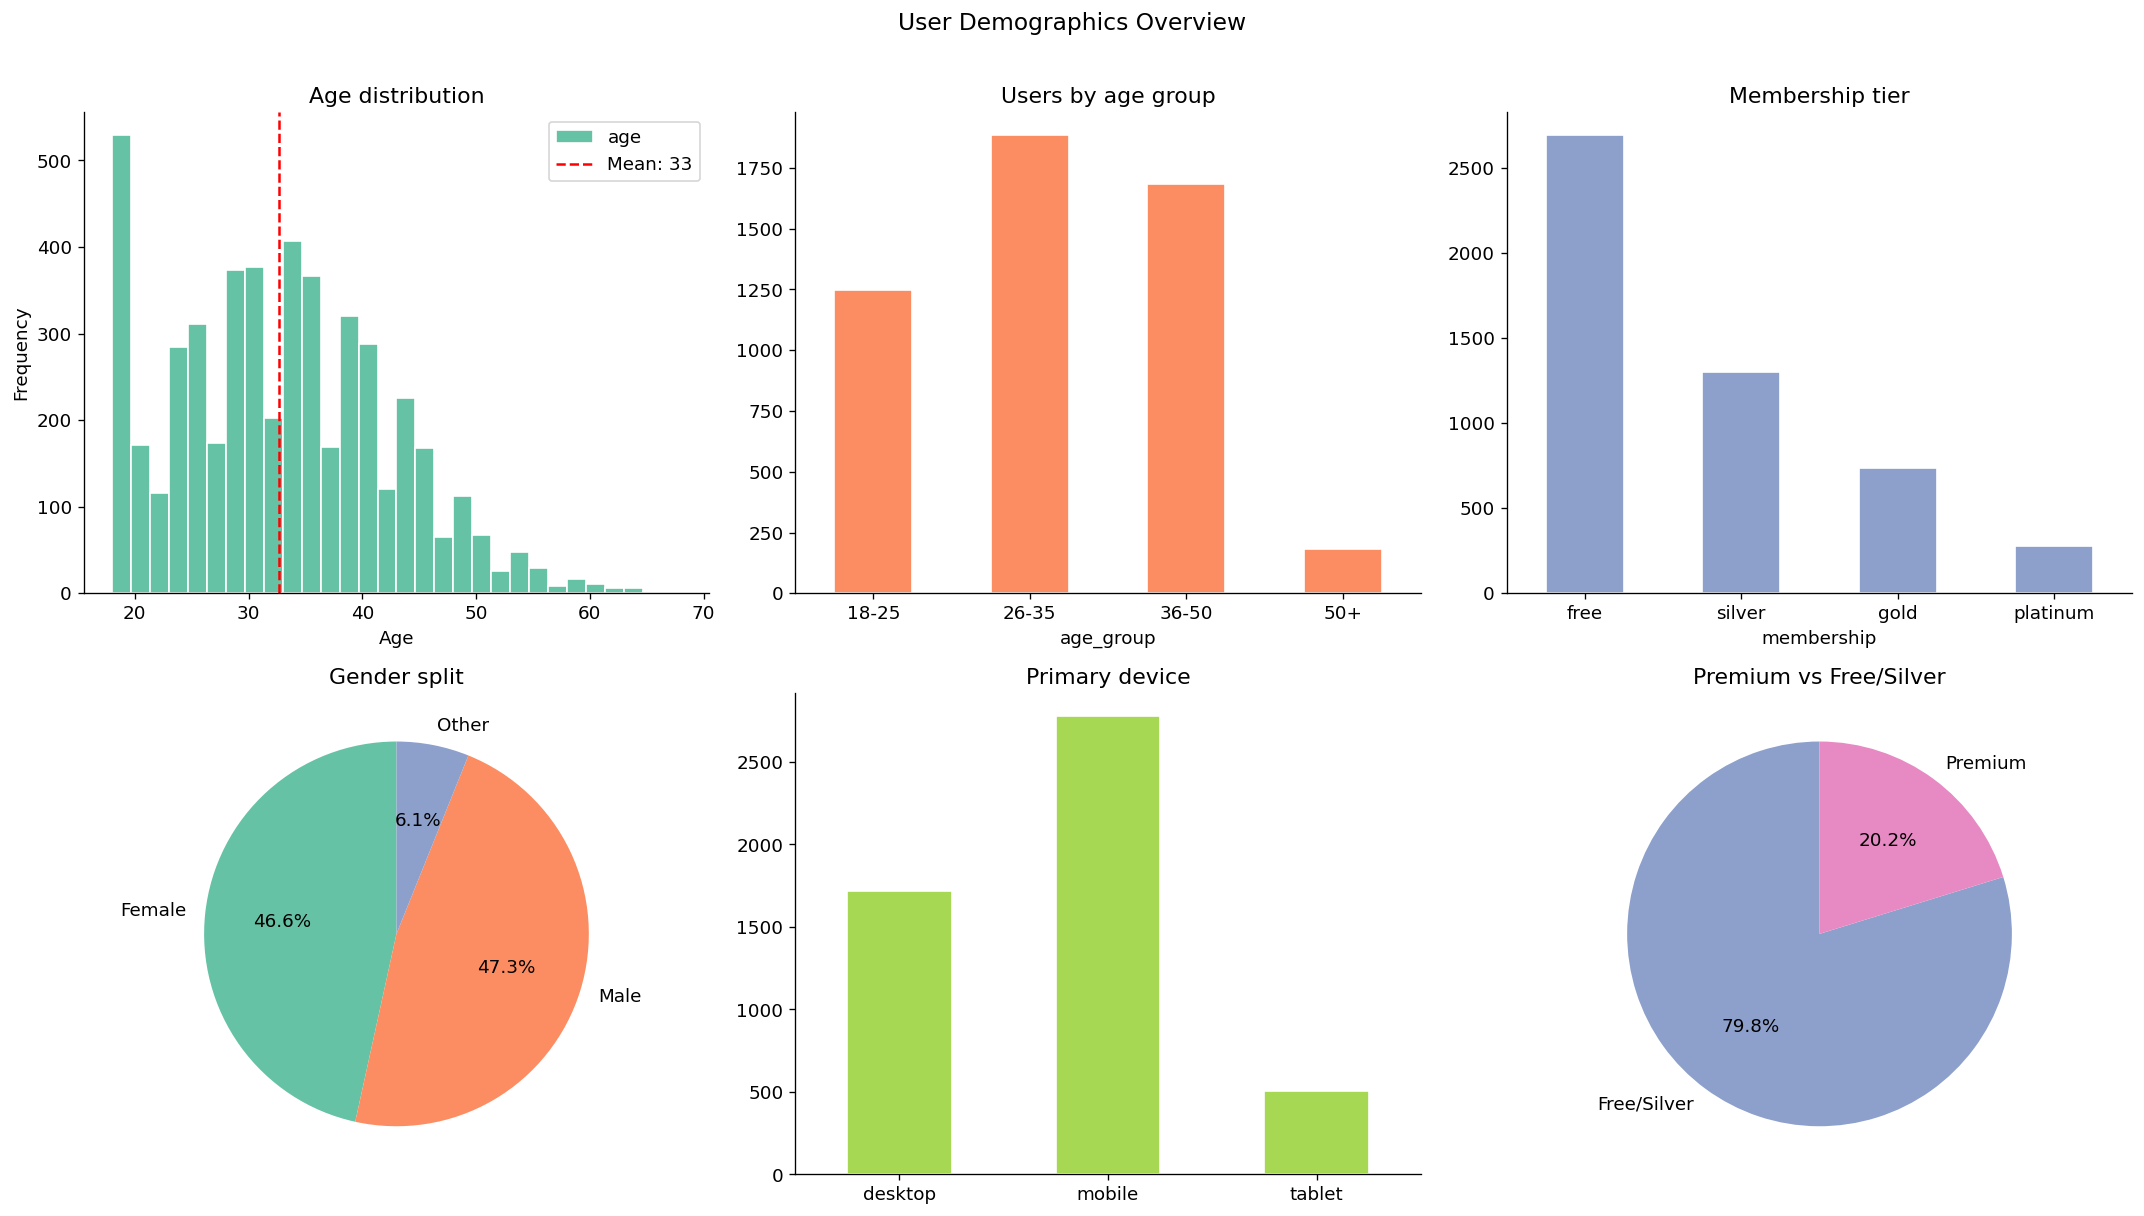

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Age distribution
users['age'].plot(kind='hist', bins=30, ax=axes[0][0], edgecolor='white', color=COLORS[0])
axes[0][0].axvline(users['age'].mean(), color='red', linestyle='--',
                   label=f"Mean: {users['age'].mean():.0f}")
axes[0][0].set_title('Age distribution')
axes[0][0].set_xlabel('Age')
axes[0][0].legend()

# Age group
if 'age_group' in users.columns:
    users['age_group'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0][1], edgecolor='white', color=COLORS[1])
    axes[0][1].set_title('Users by age group')
    axes[0][1].tick_params(axis='x', rotation=0)

# Membership tier
mem_order  = ['free','silver','gold','platinum']
mem_counts = users['membership'].value_counts()
mem_counts = mem_counts.reindex([m for m in mem_order if m in mem_counts.index])
mem_counts.plot(kind='bar', ax=axes[0][2], edgecolor='white', color=COLORS[2])
axes[0][2].set_title('Membership tier')
axes[0][2].tick_params(axis='x', rotation=0)

# Gender split
gender_cols = [c for c in users.columns if c.startswith('gender_')]
if gender_cols:
    gs = users[gender_cols].sum()
    gs.index = [c.replace('gender_','') for c in gs.index]
    gs.plot(kind='pie', ax=axes[1][0], autopct='%1.1f%%', startangle=90)
    axes[1][0].set_title('Gender split')
    axes[1][0].set_ylabel('')

# Device type
dev_cols = [c for c in users.columns if c.startswith('device_')]
if dev_cols:
    ds = users[dev_cols].sum()
    ds.index = [c.replace('device_','') for c in ds.index]
    ds.plot(kind='bar', ax=axes[1][1], edgecolor='white', color=COLORS[4])
    axes[1][1].set_title('Primary device')
    axes[1][1].tick_params(axis='x', rotation=0)

# Premium vs non-premium
if 'is_premium' in users.columns:
    users['is_premium'].map({1:'Premium','0':'Free/Silver',0:'Free/Silver'}).value_counts().plot(
        kind='pie', ax=axes[1][2], autopct='%1.1f%%', startangle=90,
        colors=[COLORS[2], COLORS[3]])
    axes[1][2].set_title('Premium vs Free/Silver')
    axes[1][2].set_ylabel('')

plt.suptitle('User Demographics Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_user_demographics.png', bbox_inches='tight')
plt.show()

In [3]:
# Buyer vs non-buyer profile comparison
buyer_ids         = set(orders['user_id'])
users['is_buyer'] = users['user_id'].isin(buyer_ids).astype(int)

num_cols = ['age','account_age_days']
if 'is_premium' in users.columns:
    num_cols.append('is_premium')

buyer_profile = users.groupby('is_buyer')[num_cols].mean().round(2)
buyer_profile.index = ['Non-Buyer','Buyer']
print("Buyer vs Non-Buyer profile:")
display(buyer_profile)
print(f"\nBuyer count : {users['is_buyer'].sum():,} / {len(users):,} ({users['is_buyer'].mean()*100:.1f}%)")

Buyer vs Non-Buyer profile:


,age,account_age_days,is_premium
Non-Buyer,32.83,338.75,0.00
Buyer,32.58,339.39,0.36



Buyer count : 2,795 / 5,000 (55.9%)


## Step 2 — Session & Browsing Behavior

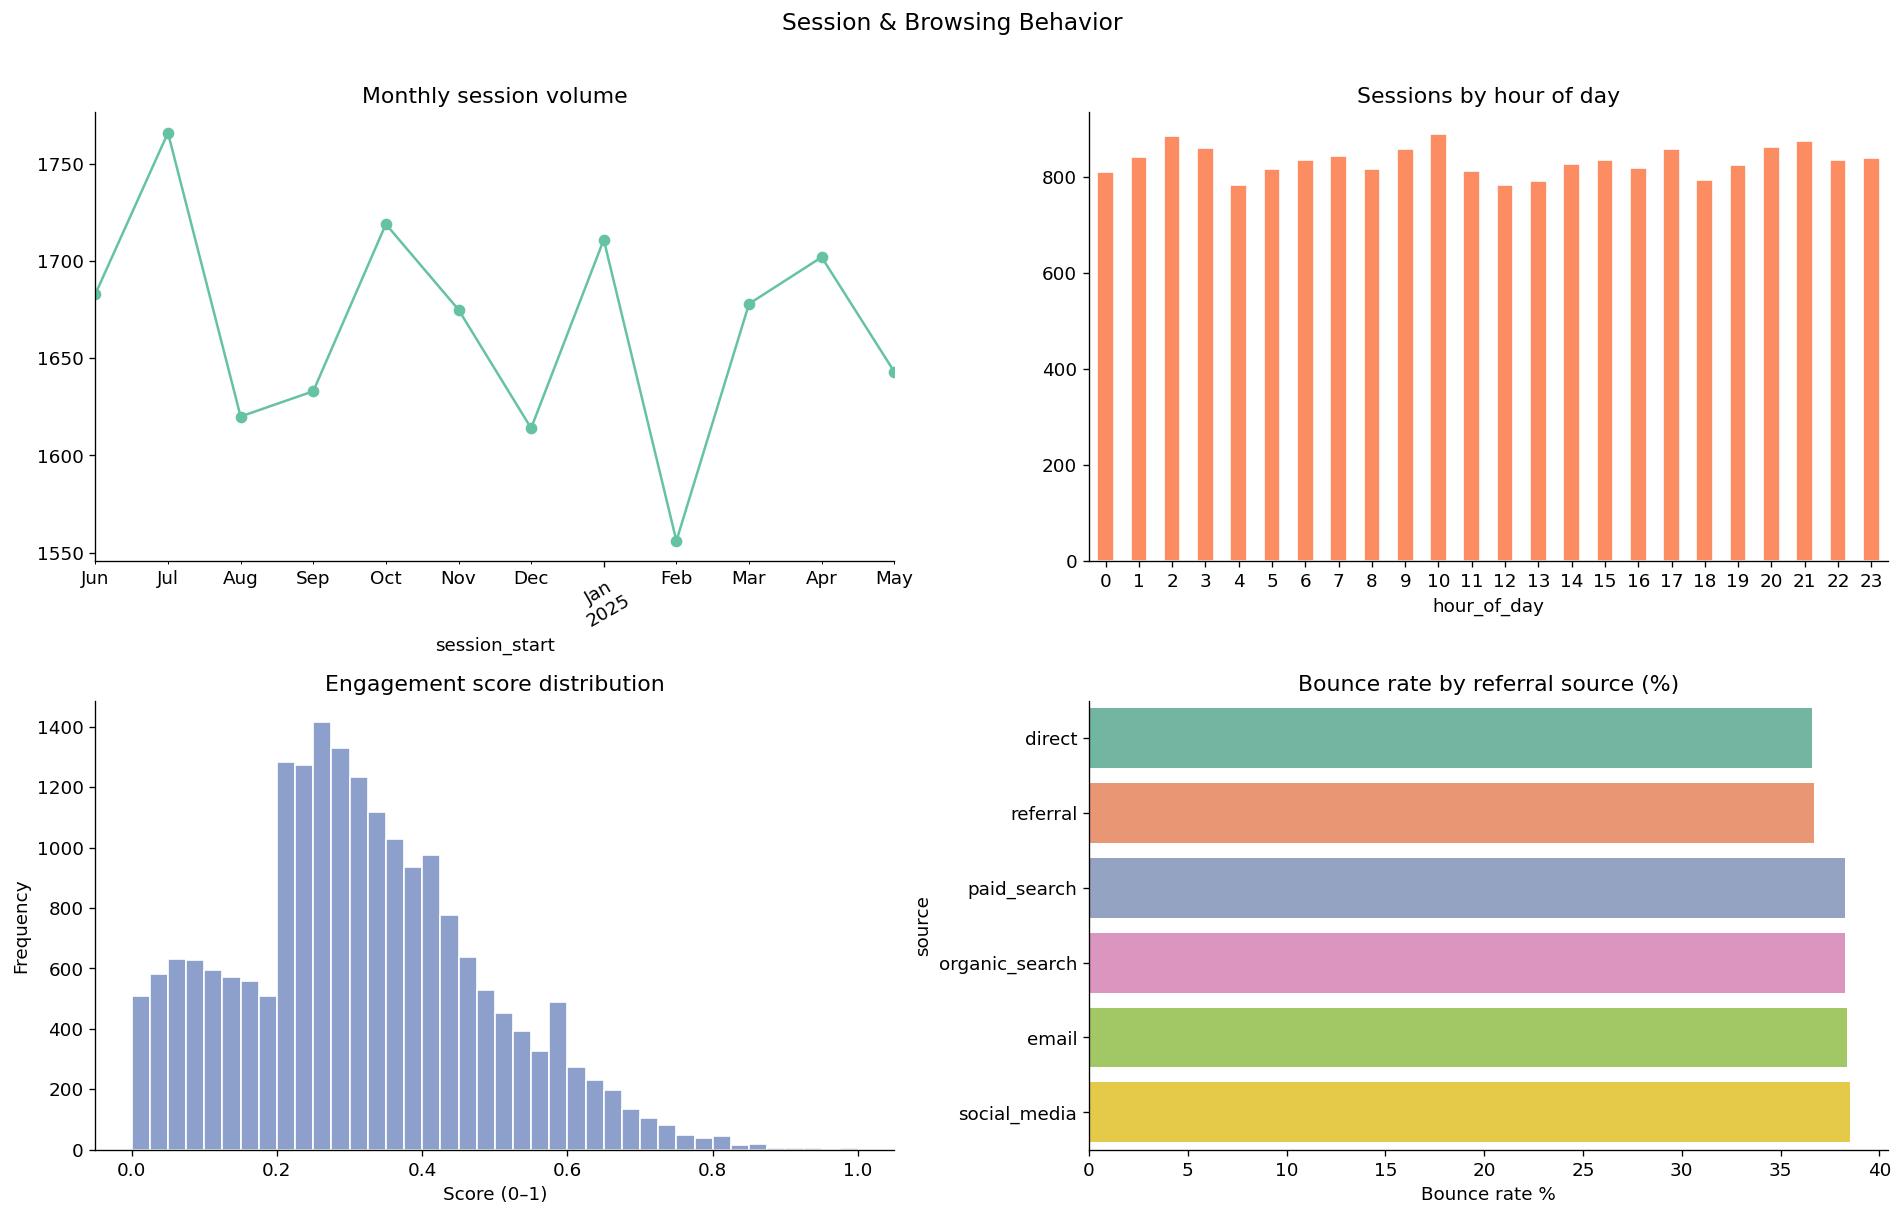

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly sessions
monthly = sessions.groupby(sessions['session_start'].dt.to_period('M')).size()
monthly.plot(kind='line', marker='o', ax=axes[0][0], color=COLORS[0])
axes[0][0].set_title('Monthly session volume')
axes[0][0].tick_params(axis='x', rotation=30)

# Hour of day
if 'hour_of_day' in sessions.columns:
    sessions.groupby('hour_of_day').size().plot(
        kind='bar', ax=axes[0][1], edgecolor='white', color=COLORS[1])
    axes[0][1].set_title('Sessions by hour of day')
    axes[0][1].tick_params(axis='x', rotation=0)

# Engagement score
if 'engagement_score' in sessions.columns:
    sessions['engagement_score'].plot(
        kind='hist', bins=40, ax=axes[1][0], edgecolor='white', color=COLORS[2])
    axes[1][0].set_title('Engagement score distribution')
    axes[1][0].set_xlabel('Score (0–1)')

# Bounce rate by referral source using seaborn
if 'bounced' in sessions.columns:
    ref_cols = [c for c in sessions.columns if c.startswith('ref_')]
    if ref_cols:
        ref_data = []
        for col in ref_cols:
            subset = sessions[sessions[col] == 1]
            if len(subset) > 0:
                ref_data.append({'source': col.replace('ref_',''),
                                 'bounce_pct': subset['bounced'].mean() * 100})
        ref_df = pd.DataFrame(ref_data).sort_values('bounce_pct')
        sns.barplot(data=ref_df, x='bounce_pct', y='source', ax=axes[1][1], palette='Set2')
        axes[1][1].set_title('Bounce rate by referral source (%)')
        axes[1][1].set_xlabel('Bounce rate %')

plt.suptitle('Session & Browsing Behavior', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_session_behavior.png', bbox_inches='tight')
plt.show()

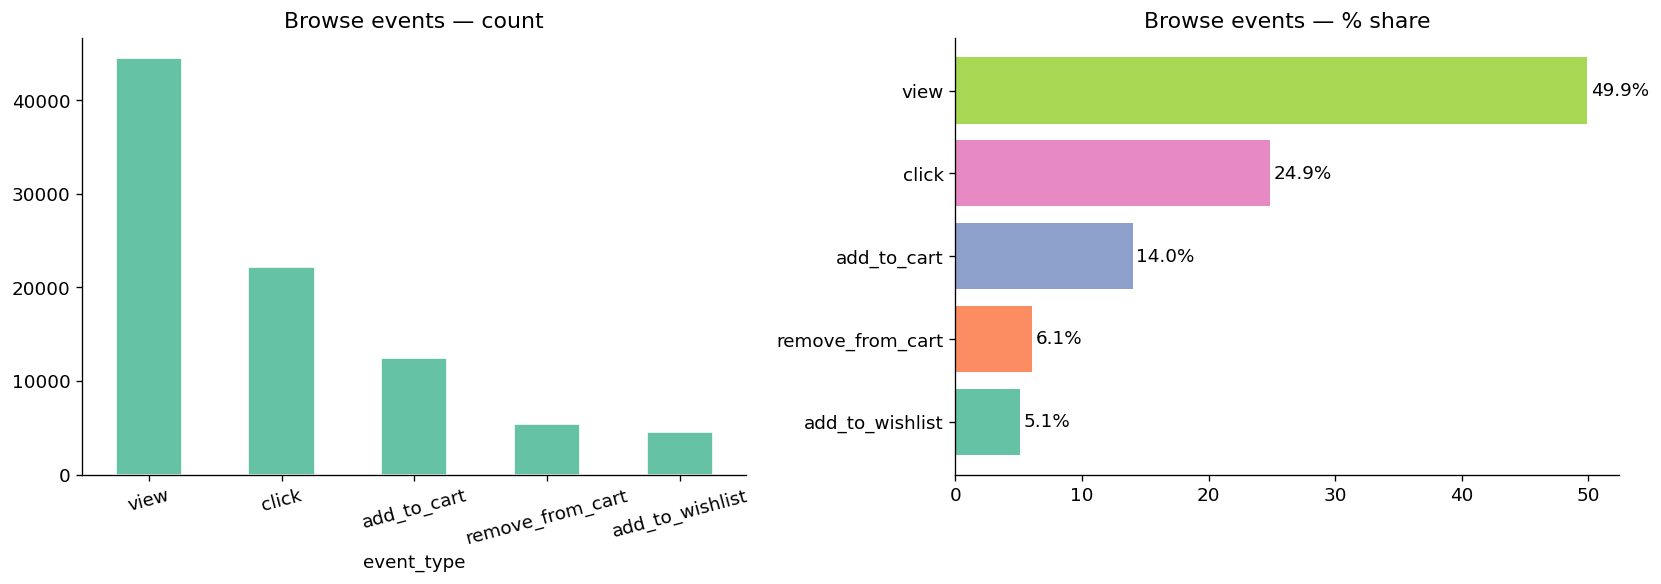

In [5]:
# Event type breakdown
event_counts = browse_events['event_type'].value_counts()
funnel_pct   = (event_counts / len(browse_events) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
event_counts.plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Browse events — count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].barh(funnel_pct.index[::-1], funnel_pct.values[::-1],
             color=[COLORS[i % len(COLORS)] for i in range(len(funnel_pct))])
for i,(idx,val) in enumerate(zip(funnel_pct.index[::-1], funnel_pct.values[::-1])):
    axes[1].text(val+0.3, i, f'{val:.1f}%', va='center')
axes[1].set_title('Browse events — % share')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_event_funnel.png', bbox_inches='tight')
plt.show()

## Step 3 — Purchase Funnel Analysis

,Stage,Users,Pct of Total,Drop-off %
0,Registered,5000,100.00,0.00
1,Had Session,4465,89.30,10.70
2,Browsed Products,4465,89.30,0.00
3,Added to Cart,3509,70.20,21.40
4,Placed Order,2795,55.90,20.30


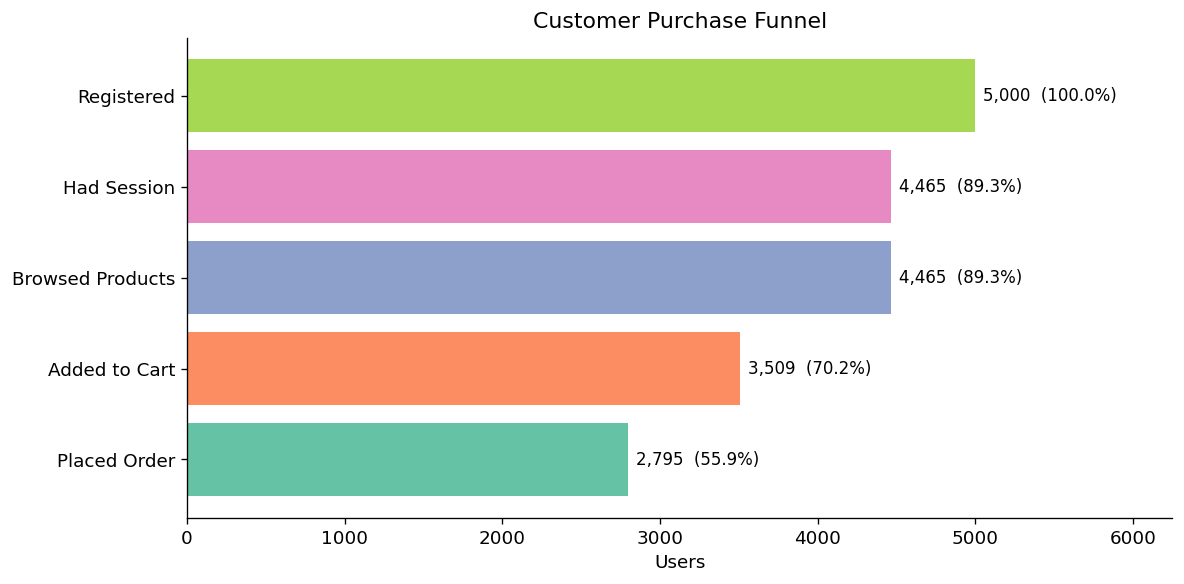

In [6]:
total_users   = len(users)
active_users  = sessions['user_id'].nunique()
browsed_users = browse_events['user_id'].nunique()
carted_users  = browse_events[browse_events['event_type']=='add_to_cart']['user_id'].nunique()
ordered_users = orders['user_id'].nunique()

funnel = pd.DataFrame({
    'Stage': ['Registered','Had Session','Browsed Products','Added to Cart','Placed Order'],
    'Users': [total_users, active_users, browsed_users, carted_users, ordered_users],
})
funnel['Pct of Total'] = (funnel['Users'] / total_users * 100).round(1)
funnel['Drop-off %']   = ((1 - funnel['Users'] / funnel['Users'].shift(1)) * 100).round(1).fillna(0)
display(funnel)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(funnel['Stage'][::-1], funnel['Users'][::-1],
               color=[COLORS[i] for i in range(len(funnel))])
for bar, row in zip(bars, funnel[::-1].itertuples()):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{row.Users:,}  ({row._3}%)", va='center', fontsize=10)
ax.set_title('Customer Purchase Funnel')
ax.set_xlabel('Users')
ax.set_xlim(0, total_users * 1.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_purchase_funnel.png', bbox_inches='tight')
plt.show()

Order value by membership tier:


,count,mean,median,total
membership,,,,
free,1629,764.37,798.11,1245151.04
silver,771,738.91,731.03,569700.34
gold,4085,746.76,739.47,3050518.96
platinum,1515,749.04,736.95,1134800.09


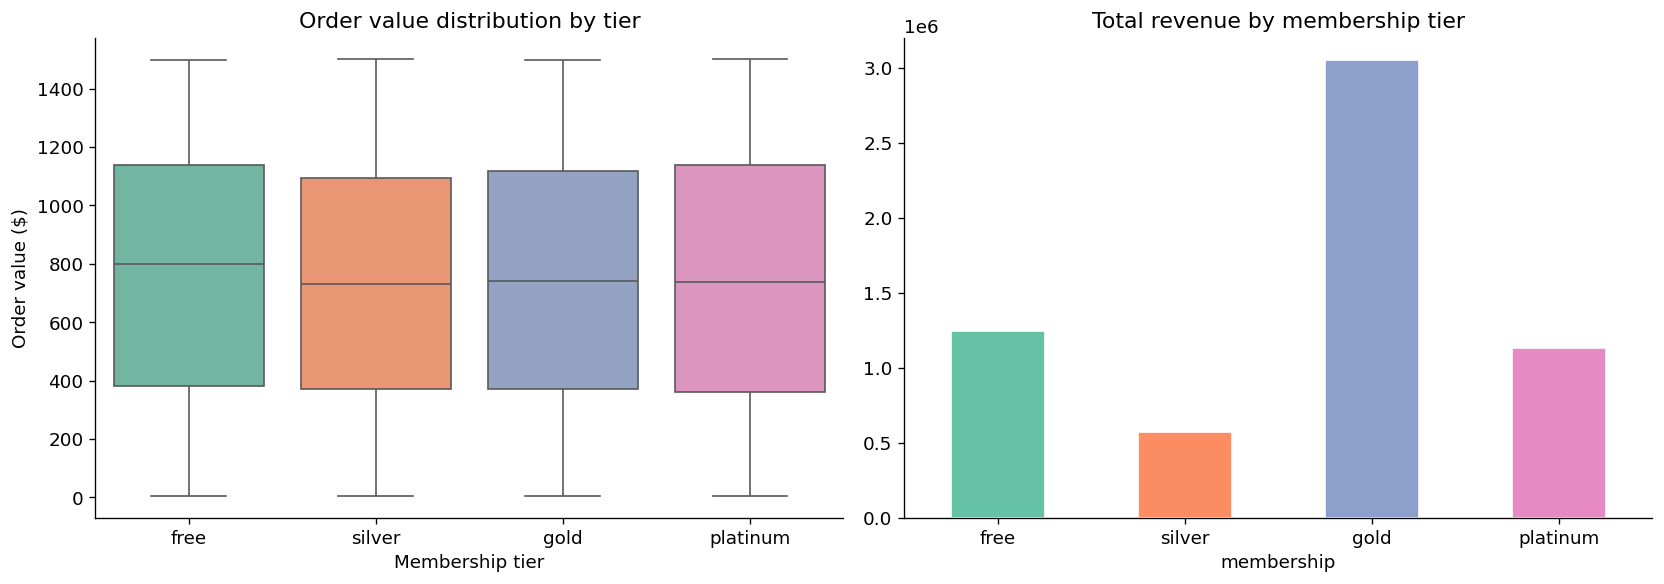

In [7]:
# Order value by membership tier — using seaborn (supports order param correctly)
merged     = orders.merge(users[['user_id','membership','is_premium']], on='user_id', how='left')
tier_order = [t for t in ['free','silver','gold','platinum']
              if t in merged['membership'].unique()]

tier_stats = (merged.groupby('membership')['total_amount']
              .agg(count='count', mean='mean', median='median', total='sum')
              .round(2).reindex(tier_order))

print("Order value by membership tier:")
display(tier_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# seaborn boxplot — correctly handles order parameter
sns.boxplot(data=merged, x='membership', y='total_amount',
            order=tier_order, ax=axes[0], palette='Set2')
axes[0].set_title('Order value distribution by tier')
axes[0].set_xlabel('Membership tier')
axes[0].set_ylabel('Order value ($)')

tier_stats['total'].plot(kind='bar', ax=axes[1], edgecolor='white', color=COLORS)
axes[1].set_title('Total revenue by membership tier')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_revenue_by_tier.png', bbox_inches='tight')
plt.show()

## Step 4 — Product Performance Analysis

In [8]:
# Top browsed products
top_browsed = (browse_events.groupby('product_id').size()
               .reset_index(name='browse_count')
               .merge(products[['product_id','product_name','category','price']], on='product_id')
               .sort_values('browse_count', ascending=False))

print("Top 10 most browsed products:")
display(top_browsed.head(10)[['product_name','category','price','browse_count']])

Top 10 most browsed products:


,product_name,category,price,browse_count
421,Fragrance — Model 496,Beauty,190.24,2462
414,Kitchen — Model 487,Home & Garden,62.66,2354
5,Pants — Model 007,Clothing,297.78,1676
307,Laptops — Model 356,Electronics,404.15,1540
222,Fitness — Model 260,Sports,385.48,1495
187,Team Sports — Model 219,Sports,14.47,1442
197,Tablets — Model 233,Electronics,1338.70,1343
298,Fiction — Model 347,Books,41.27,1324
239,Pants — Model 280,Clothing,107.49,1259
123,Hair Care — Model 140,Beauty,189.71,1212


In [9]:
# Revenue per product
oi = order_items.copy()
oi['line_revenue'] = oi['quantity'] * oi['unit_price']

top_sold = (oi.groupby('product_id')
            .agg(units_sold=('quantity','sum'), revenue=('line_revenue','sum'))
            .reset_index()
            .merge(products[['product_id','product_name','category','price']], on='product_id')
            .sort_values('revenue', ascending=False))

print("Top 10 products by revenue:")
display(top_sold.head(10)[['product_name','category','price','units_sold','revenue']])

Top 10 products by revenue:


,product_name,category,price,units_sold,revenue
439,Cameras — Model 440,Electronics,1846.94,150,277041.00
29,Smartphones — Model 030,Electronics,1811.46,148,268096.08
301,Tablets — Model 302,Electronics,1899.25,119,226010.75
315,Headphones — Model 316,Electronics,1901.39,115,218659.85
470,Tablets — Model 471,Electronics,1776.09,121,214906.89
118,Smartphones — Model 119,Electronics,1786.37,119,212578.03
32,Smartphones — Model 033,Electronics,1706.96,124,211663.04
248,Tablets — Model 249,Electronics,1641.72,128,210140.16
257,Smartphones — Model 258,Electronics,1455.84,144,209640.96
493,Cameras — Model 494,Electronics,1472.28,140,206119.20


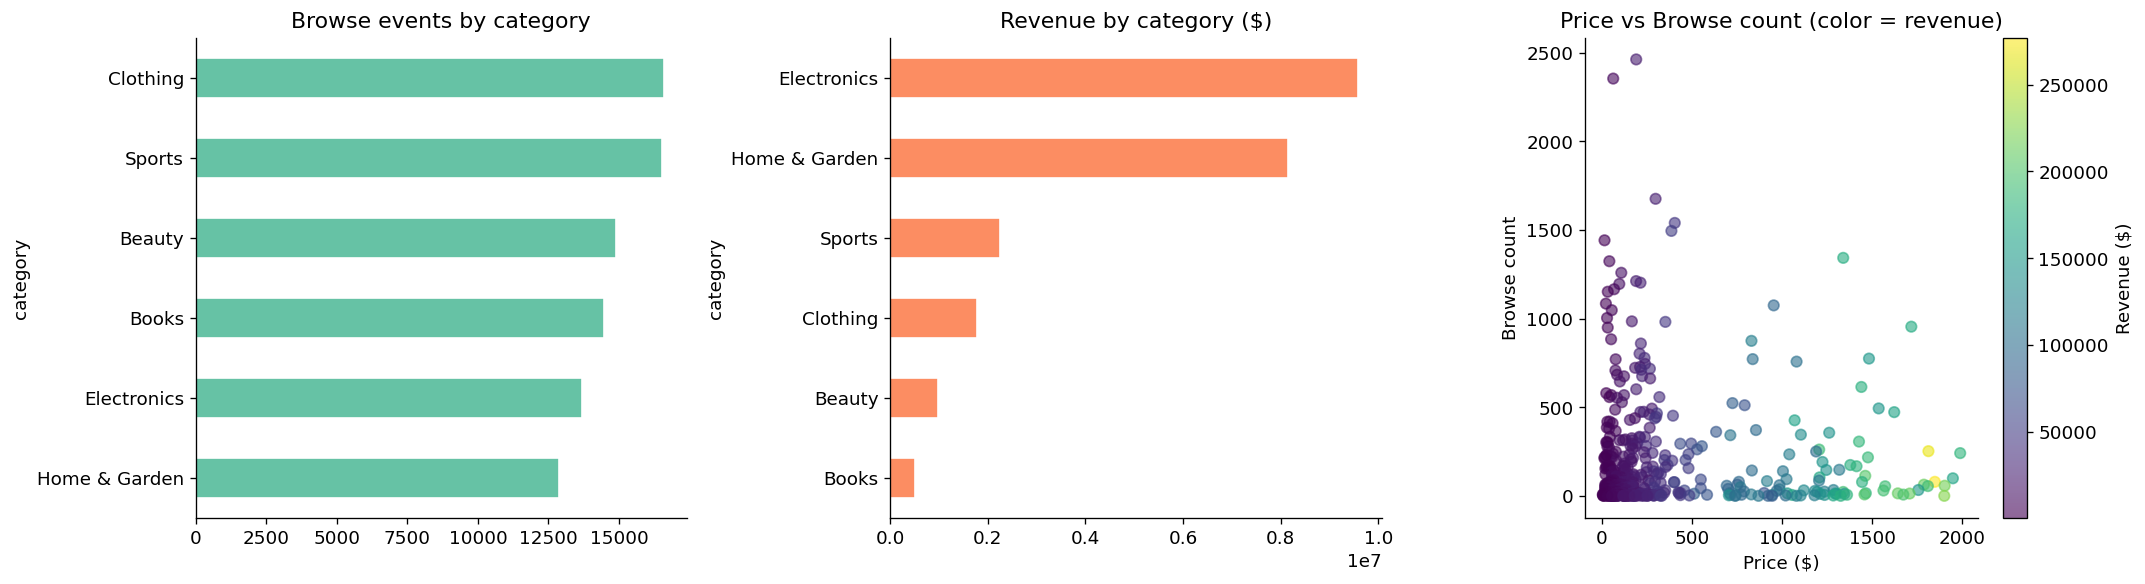

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_browse = (browse_events
              .merge(products[['product_id','category']], on='product_id')
              .groupby('category').size().sort_values())
cat_browse.plot(kind='barh', ax=axes[0], edgecolor='white', color=COLORS[0])
axes[0].set_title('Browse events by category')

cat_rev = top_sold.groupby('category')['revenue'].sum().sort_values()
cat_rev.plot(kind='barh', ax=axes[1], edgecolor='white', color=COLORS[1])
axes[1].set_title('Revenue by category ($)')

# Price vs browse scatter
merged_prod = top_browsed.merge(top_sold[['product_id','revenue']], on='product_id', how='left').fillna(0)
sc = axes[2].scatter(merged_prod['price'], merged_prod['browse_count'],
                     c=merged_prod['revenue'], cmap='viridis', alpha=0.6, s=40)
plt.colorbar(sc, ax=axes[2], label='Revenue ($)')
axes[2].set_title('Price vs Browse count (color = revenue)')
axes[2].set_xlabel('Price ($)')
axes[2].set_ylabel('Browse count')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_product_analysis.png', bbox_inches='tight')
plt.show()

## Step 5 — RFM Analysis
**Recency · Frequency · Monetary** — scores each customer on 3 dimensions (1–4 each).


In [11]:
snapshot = orders['order_date'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('user_id').agg(
    recency   = ('order_date',   lambda x: (snapshot - x.max()).days),
    frequency = ('order_id',     'count'),
    monetary  = ('total_amount', 'sum'),
).reset_index()

rfm['R_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1,2,3,4]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def segment(row):
    if   row['RFM_score'] >= 10:                       return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:  return 'Loyal'
    elif row['R_score'] >= 3:                          return 'Recent'
    elif row['F_score'] >= 3:                          return 'At Risk'
    elif row['RFM_score'] <= 5:                        return 'Lost'
    else:                                               return 'Potential'

rfm['segment'] = rfm.apply(segment, axis=1)

seg_summary = rfm.groupby('segment').agg(
    count=('user_id','count'), avg_spend=('monetary','mean'),
    avg_freq=('frequency','mean'), avg_recency=('recency','mean'),
).sort_values('avg_spend', ascending=False).round(1)

print("RFM Segment Summary:")
display(seg_summary)

RFM Segment Summary:


,count,avg_spend,avg_freq,avg_recency
segment,,,,
Champions,845,4621.40,6.00,40.50
At Risk,340,1929.50,2.60,172.60
Loyal,212,1611.80,2.50,57.60
Potential,166,1266.30,1.10,179.00
Recent,405,814.80,1.10,48.00
Lost,827,673.70,1.00,240.10


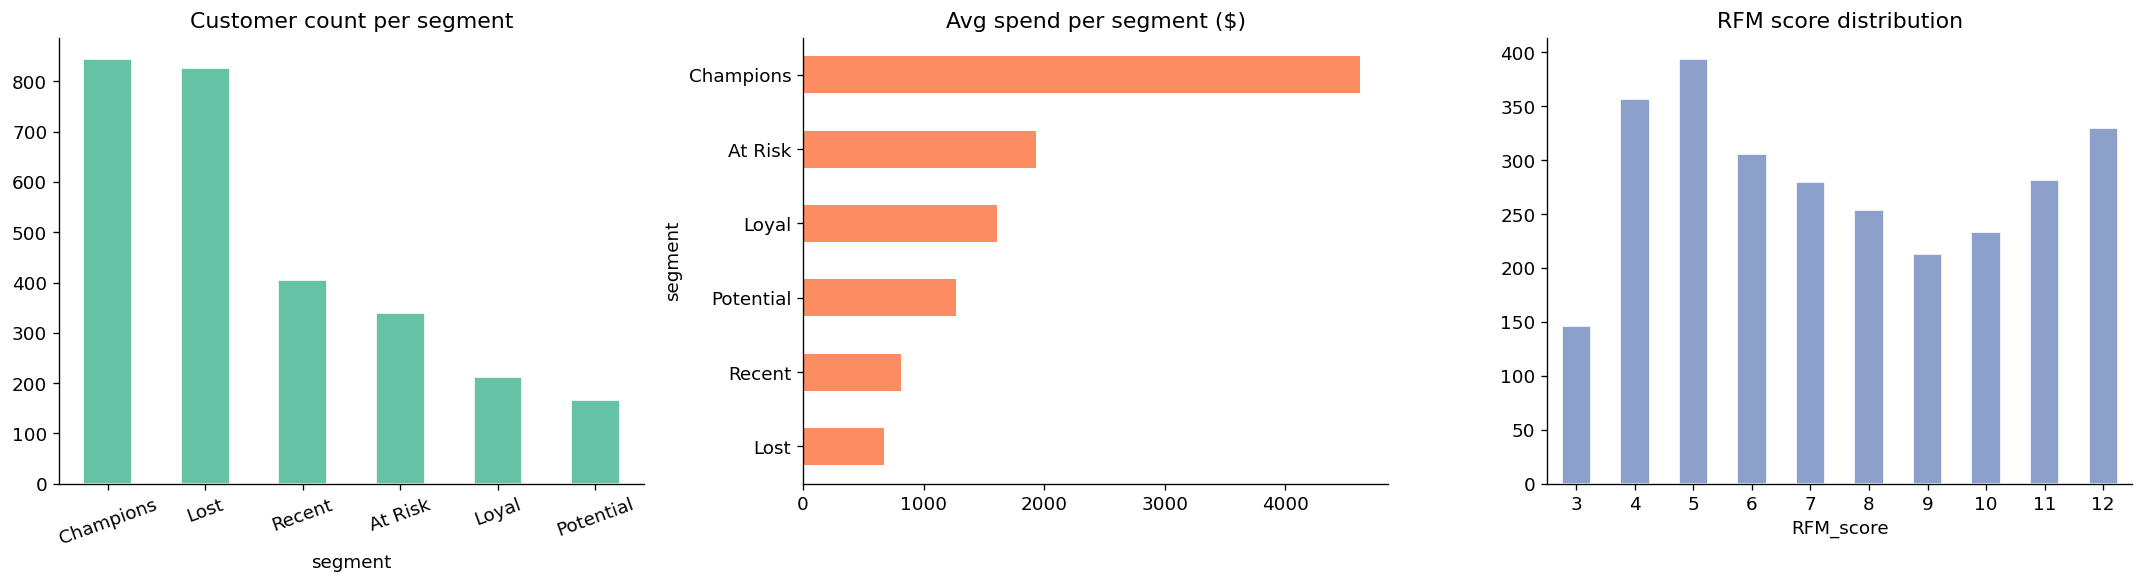

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rfm['segment'].value_counts().plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Customer count per segment')
axes[0].tick_params(axis='x', rotation=20)

seg_summary['avg_spend'].sort_values().plot(kind='barh', ax=axes[1], color=COLORS[1])
axes[1].set_title('Avg spend per segment ($)')

rfm['RFM_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], edgecolor='white', color=COLORS[2])
axes[2].set_title('RFM score distribution')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_rfm_analysis.png', bbox_inches='tight')
plt.show()

## Step 6 — Correlation Heatmap

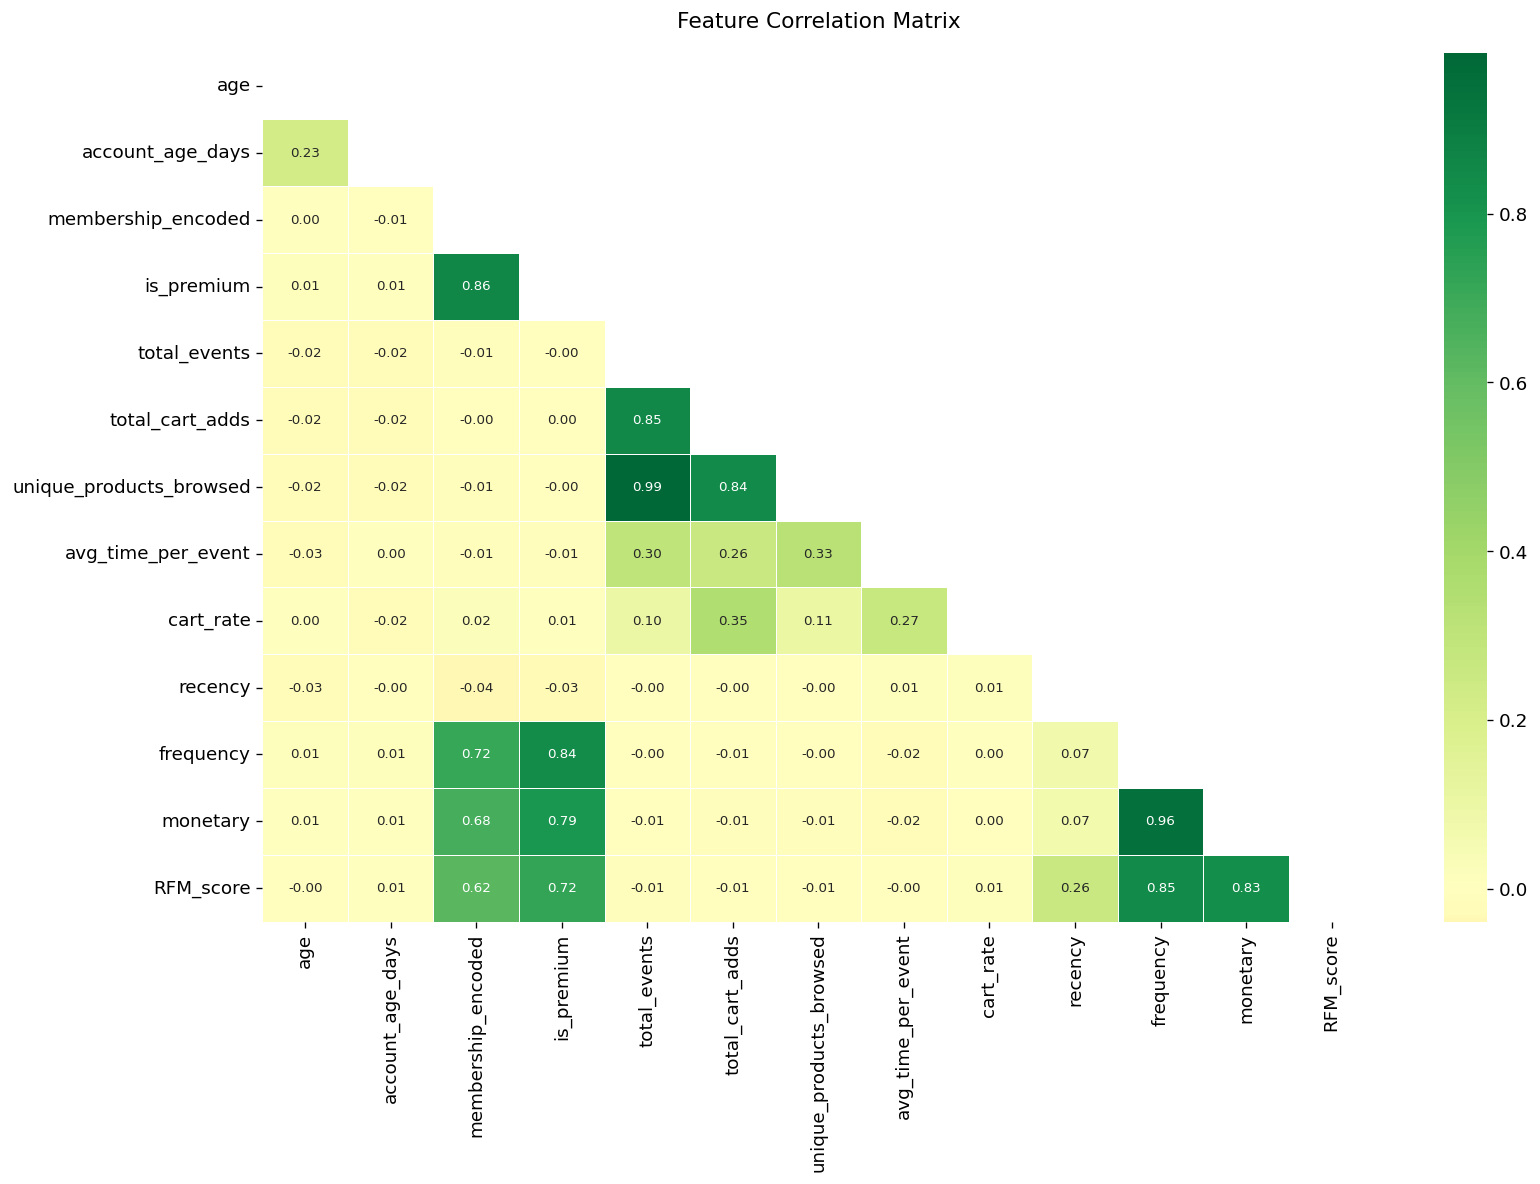


Top features correlated with spend (monetary):
frequency            0.96
RFM_score            0.83
is_premium           0.79
membership_encoded   0.68
recency              0.07
avg_time_per_event   0.02


In [13]:
# Build user-level feature matrix
base_cols = ['user_id','age','account_age_days']
if 'membership_encoded' in users.columns: base_cols.append('membership_encoded')
if 'is_premium'         in users.columns: base_cols.append('is_premium')

user_features = (
    users[base_cols]
    .merge(cart_signals[['user_id','total_events','total_cart_adds',
                          'unique_products_browsed','avg_time_per_event','cart_rate']],
           on='user_id', how='left')
    .merge(rfm[['user_id','recency','frequency','monetary','RFM_score']],
           on='user_id', how='left')
    .fillna(0)
)

corr = user_features.drop(columns=['user_id']).corr().round(3)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

if 'monetary' in corr.columns:
    top = corr['monetary'].drop('monetary').abs().sort_values(ascending=False).head(6)
    print("\nTop features correlated with spend (monetary):")
    print(top.to_string())

## Step 7 — Key Insights Summary

In [14]:
print("=" * 60)
print("  EDA — KEY FINDINGS")
print("=" * 60)

print(f"\n1. Buyer rate          : {orders['user_id'].nunique()/len(users)*100:.1f}% of users purchased")

if 'bounced' in sessions.columns:
    print(f"2. Bounce rate         : {sessions['bounced'].mean()*100:.1f}% of sessions")

best_tier = merged.groupby('membership')['total_amount'].mean().idxmax()
best_val  = merged.groupby('membership')['total_amount'].mean().max()
print(f"3. Highest avg order   : {best_tier} members (${best_val:.2f})")

if 'category' in cat_rev.index.name or True:
    print(f"4. Top revenue category: {cat_rev.idxmax()}")

champ = rfm[rfm['segment']=='Champions']
print(f"5. Champions segment   : {len(champ):,} users, avg ${champ['monetary'].mean():.2f} spend")

if 'cart_rate' in cart_signals.columns:
    print(f"6. Avg cart-add rate   : {cart_signals['cart_rate'].mean()*100:.1f}% of events")

if 'hour_of_day' in sessions.columns:
    print(f"7. Peak session hour   : {sessions['hour_of_day'].value_counts().idxmax()}:00")

print("\n" + "=" * 60)
print("  Phase 3 complete ✓ — open 04_feature_engineering.ipynb")
print("=" * 60)

  EDA — KEY FINDINGS

1. Buyer rate          : 55.9% of users purchased
2. Bounce rate         : 37.8% of sessions
3. Highest avg order   : free members ($764.37)
4. Top revenue category: Electronics
5. Champions segment   : 845 users, avg $4621.44 spend
6. Avg cart-add rate   : 14.2% of events
7. Peak session hour   : 10:00

  Phase 3 complete ✓ — open 04_feature_engineering.ipynb


## ✅ Phase 3 Complete

### Charts saved to `reports/figures/`
| File | Content |
|---|---|
| `03_user_demographics.png` | Age, gender, device, membership |
| `03_session_behavior.png` | Monthly trend, hourly, engagement, bounce |
| `03_event_funnel.png` | Browse event breakdown |
| `03_purchase_funnel.png` | Full conversion funnel |
| `03_revenue_by_tier.png` | Order value & revenue by tier |
| `03_product_analysis.png` | Category & product performance |
| `03_rfm_analysis.png` | RFM customer segments |
| `03_correlation_heatmap.png` | Feature correlation matrix |

### ⏭️ Next: Phase 4 — Feature Engineering
